## Load and Prepare Data




In [13]:
df.info()
print("\nMissing values per column:")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107378 entries, 0 to 107377
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       107378 non-null  object        
 1   location_name                 107378 non-null  object        
 2   latitude                      107378 non-null  float64       
 3   longitude                     107378 non-null  float64       
 4   timezone                      107378 non-null  object        
 5   last_updated_epoch            107378 non-null  int64         
 6   last_updated                  107378 non-null  datetime64[ns]
 7   temperature_celsius           107378 non-null  float64       
 8   condition_text                107378 non-null  object        
 9   wind_kph                      107378 non-null  float64       
 10  wind_degree                   107378 non-null  int64         
 11  wind_directio

,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
condition_text,0
wind_kph,0


In [14]:
df['last_updated_datetime'] = pd.to_datetime(df['last_updated_epoch'], unit='s')
df['year'] = df['last_updated_datetime'].dt.year
df['month'] = df['last_updated_datetime'].dt.month
df['day'] = df['last_updated_datetime'].dt.day
df['hour'] = df['last_updated_datetime'].dt.hour
print("Converted 'last_updated_epoch' to datetime and extracted year, month, day, and hour.")
print(df[['last_updated_epoch', 'last_updated_datetime', 'year', 'month', 'day', 'hour']].head())

Converted 'last_updated_epoch' to datetime and extracted year, month, day, and hour.
   last_updated_epoch last_updated_datetime  year  month  day  hour
0          1715849100   2024-05-16 08:45:00  2024      5   16     8
1          1715849100   2024-05-16 08:45:00  2024      5   16     8
2          1715849100   2024-05-16 08:45:00  2024      5   16     8
3          1715849100   2024-05-16 08:45:00  2024      5   16     8
4          1715849100   2024-05-16 08:45:00  2024      5   16     8


## Analyze distributions




In [15]:
descriptive_stats = df.describe()
print("Descriptive Statistics for Numerical Columns:")
print(descriptive_stats)

Descriptive Statistics for Numerical Columns:
           latitude      longitude  last_updated_epoch  \
count  107378.00000  107378.000000        1.073780e+05   
mean       19.16825      22.047441        1.739749e+09   
min       -41.30000    -175.200000        1.715849e+09   
25%         3.75000      -6.836100        1.727861e+09   
50%        17.25000      23.316700        1.739787e+09   
75%        40.40000      50.580000        1.751705e+09   
max        64.15000     179.220000        1.763536e+09   
std        24.44401      65.803704        1.379054e+07   

                        last_updated  temperature_celsius       wind_kph  \
count                         107378        107378.000000  107378.000000   
mean   2025-02-17 01:46:56.730615296             0.640335       0.035343   
min              2024-05-16 01:45:00             0.000000       0.000000   
25%              2024-10-02 10:30:00             0.570850       0.010797   
50%              2025-02-17 12:15:00             0.

## Visualize distributions of key numerical features




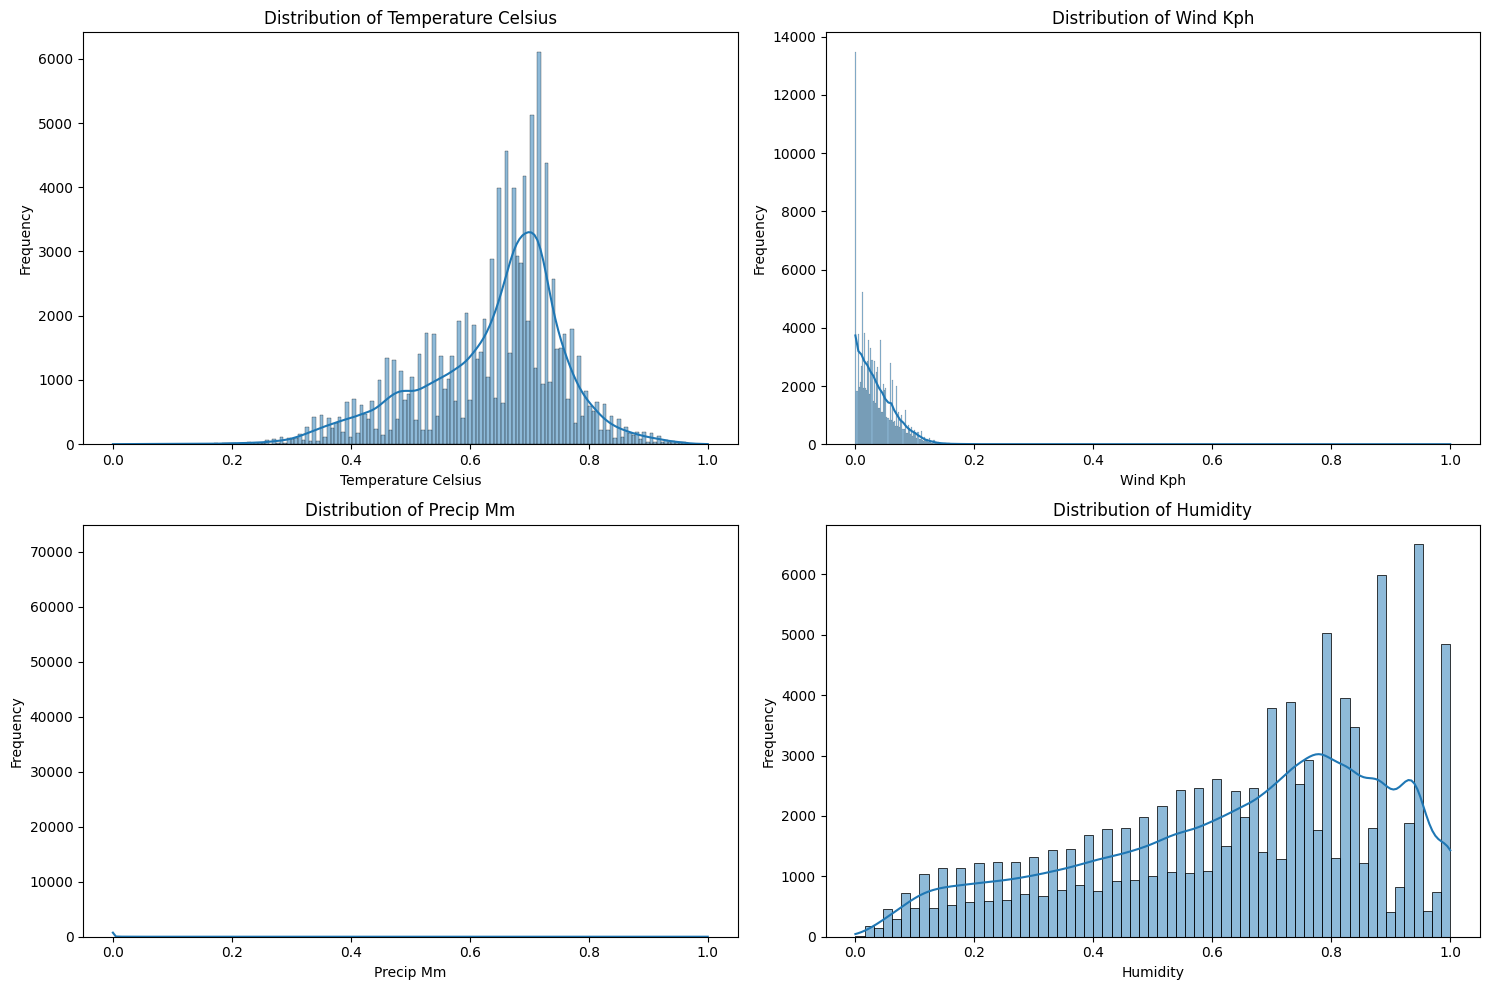

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the key numerical features to visualize
key_features = ['temperature_celsius', 'wind_kph', 'precip_mm', 'humidity']

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

# Generate histograms for each feature
for i, feature in enumerate(key_features):
    sns.histplot(df[feature], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature.replace("_", " ").title()}')
    axes[i].set_xlabel(feature.replace("_", " ").title())
    axes[i].set_ylabel('Frequency')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
plt.show()


## Analyze correlations

### Subtask:
Analyze correlations between numerical weather parameters to identify relationships.


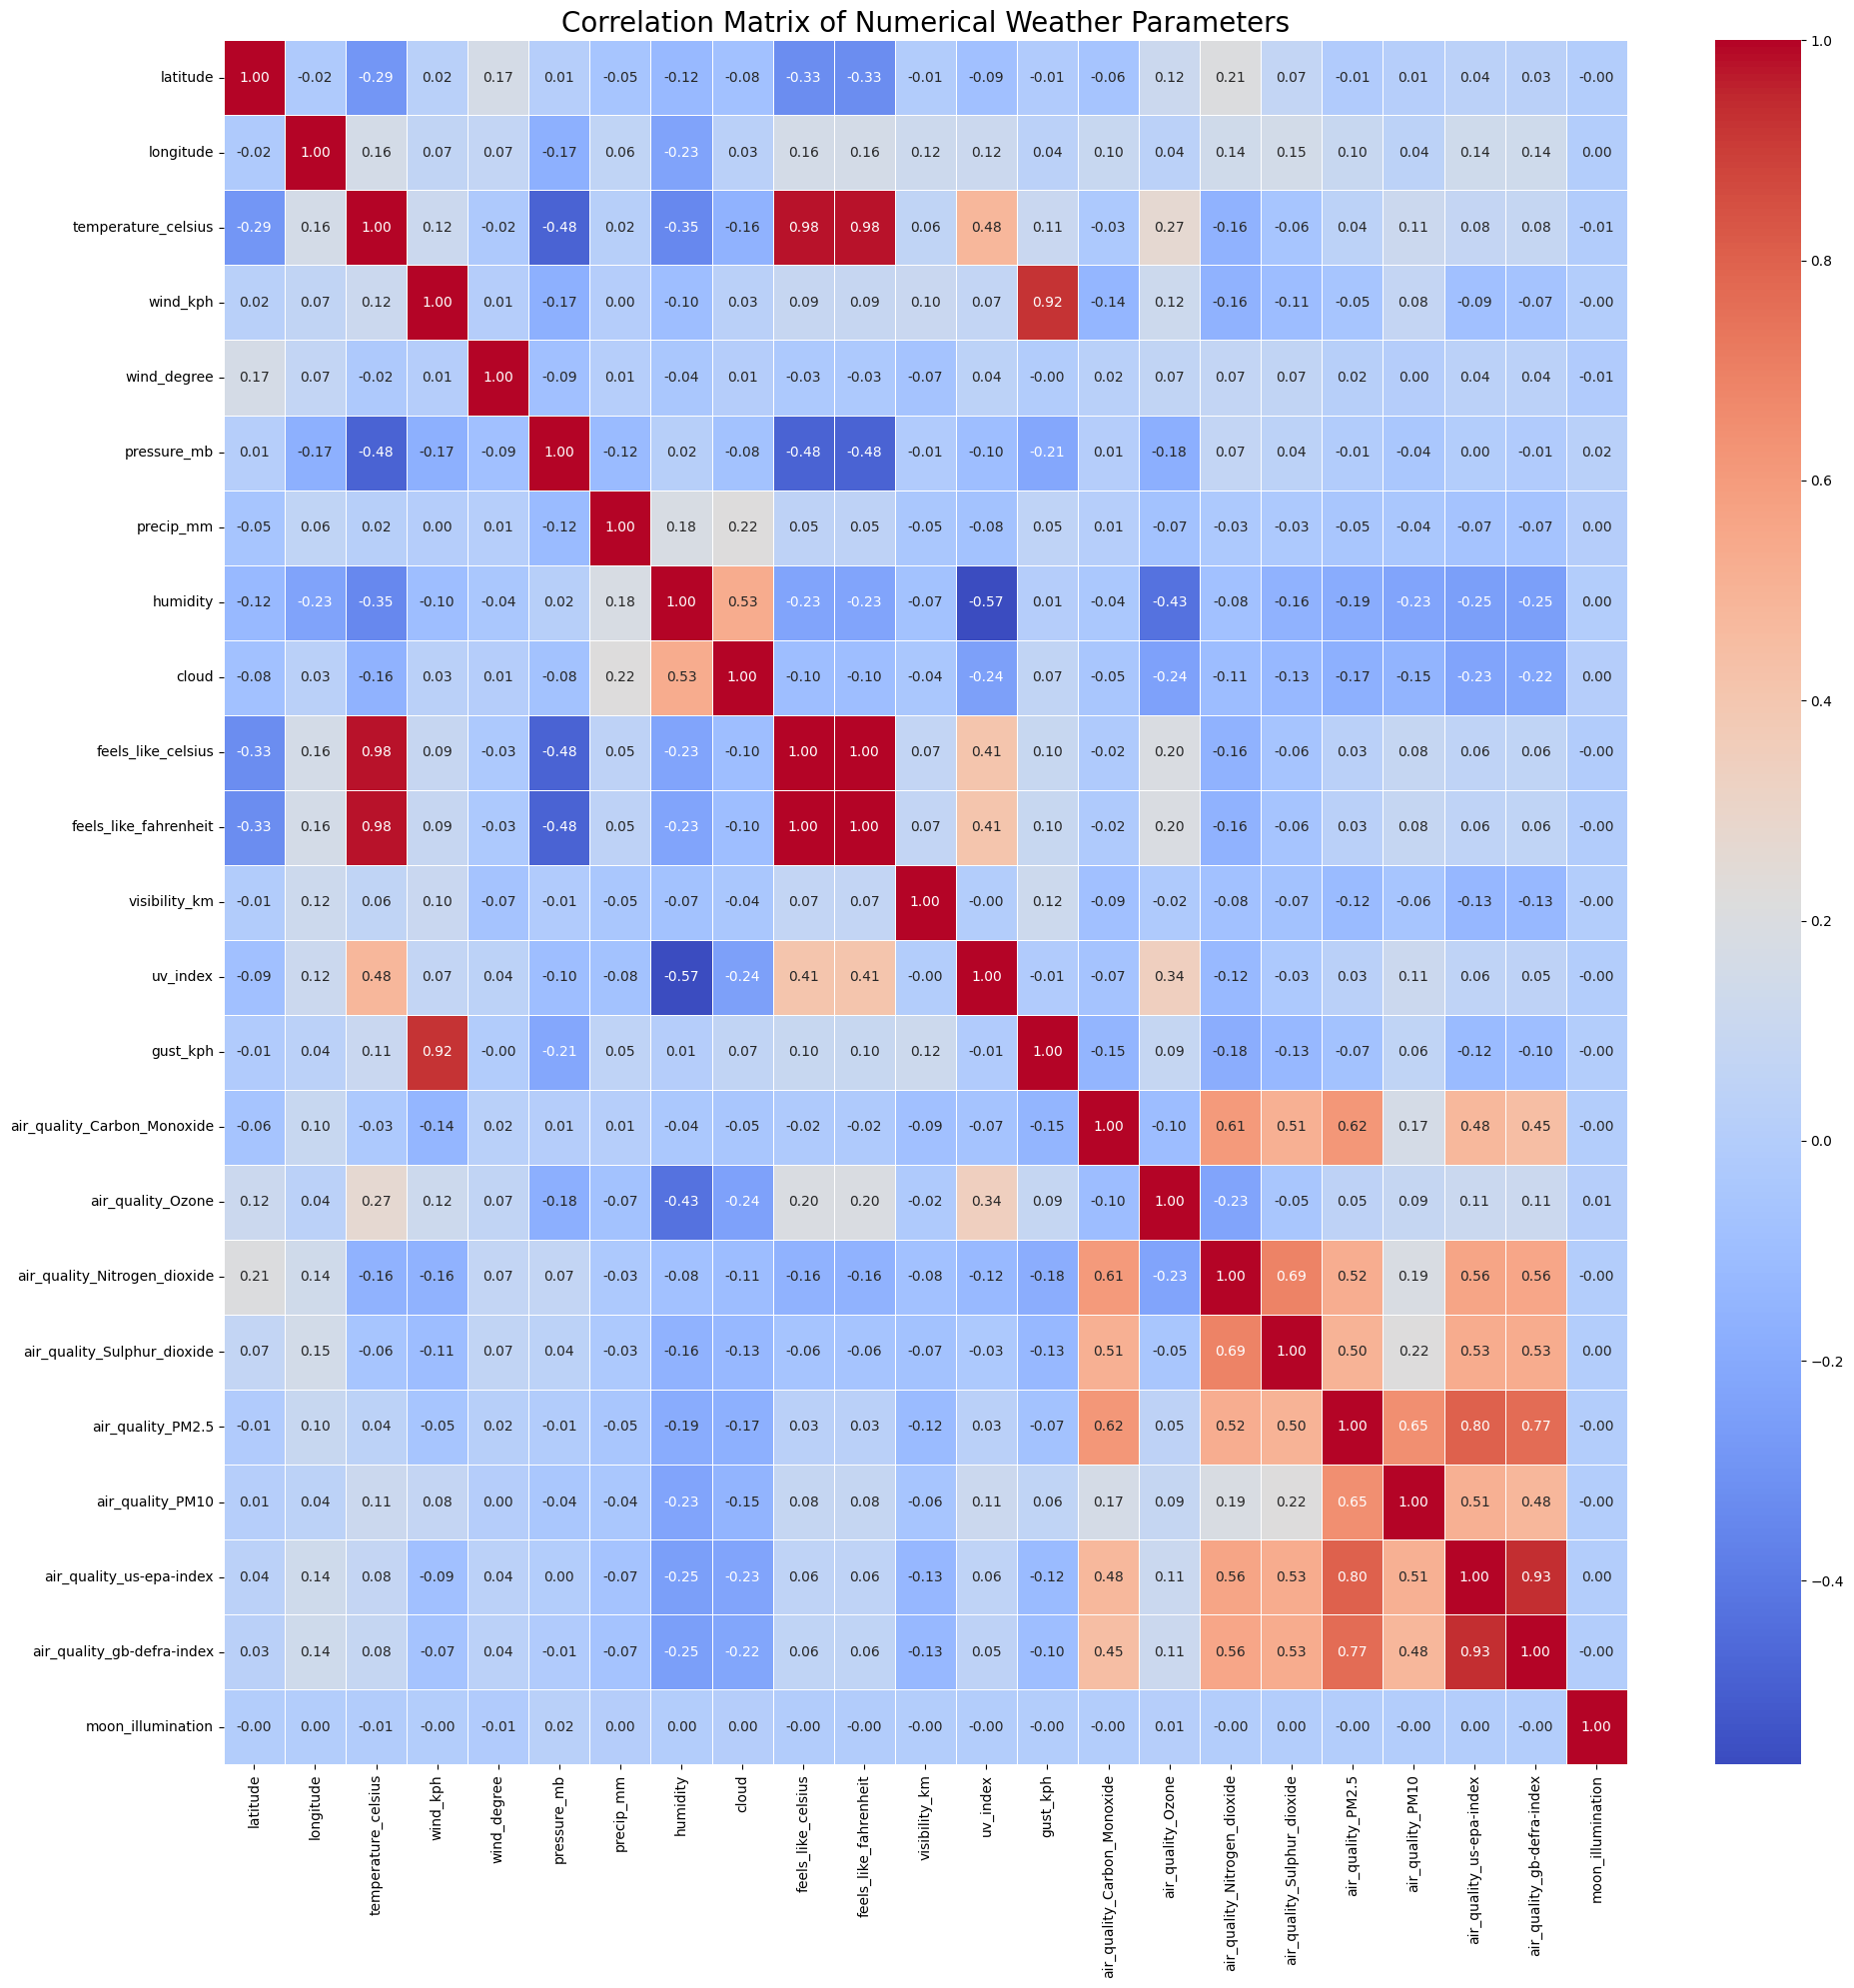

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    'latitude', 'longitude', 'temperature_celsius', 'wind_kph', 'wind_degree',
    'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius',
    'feels_like_fahrenheit', 'visibility_km', 'uv_index', 'gust_kph',
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
    'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'moon_illumination'
]


correlation_matrix = df[numerical_cols].corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Weather Parameters', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Analyze seasonal patterns and trends in key weather parameters



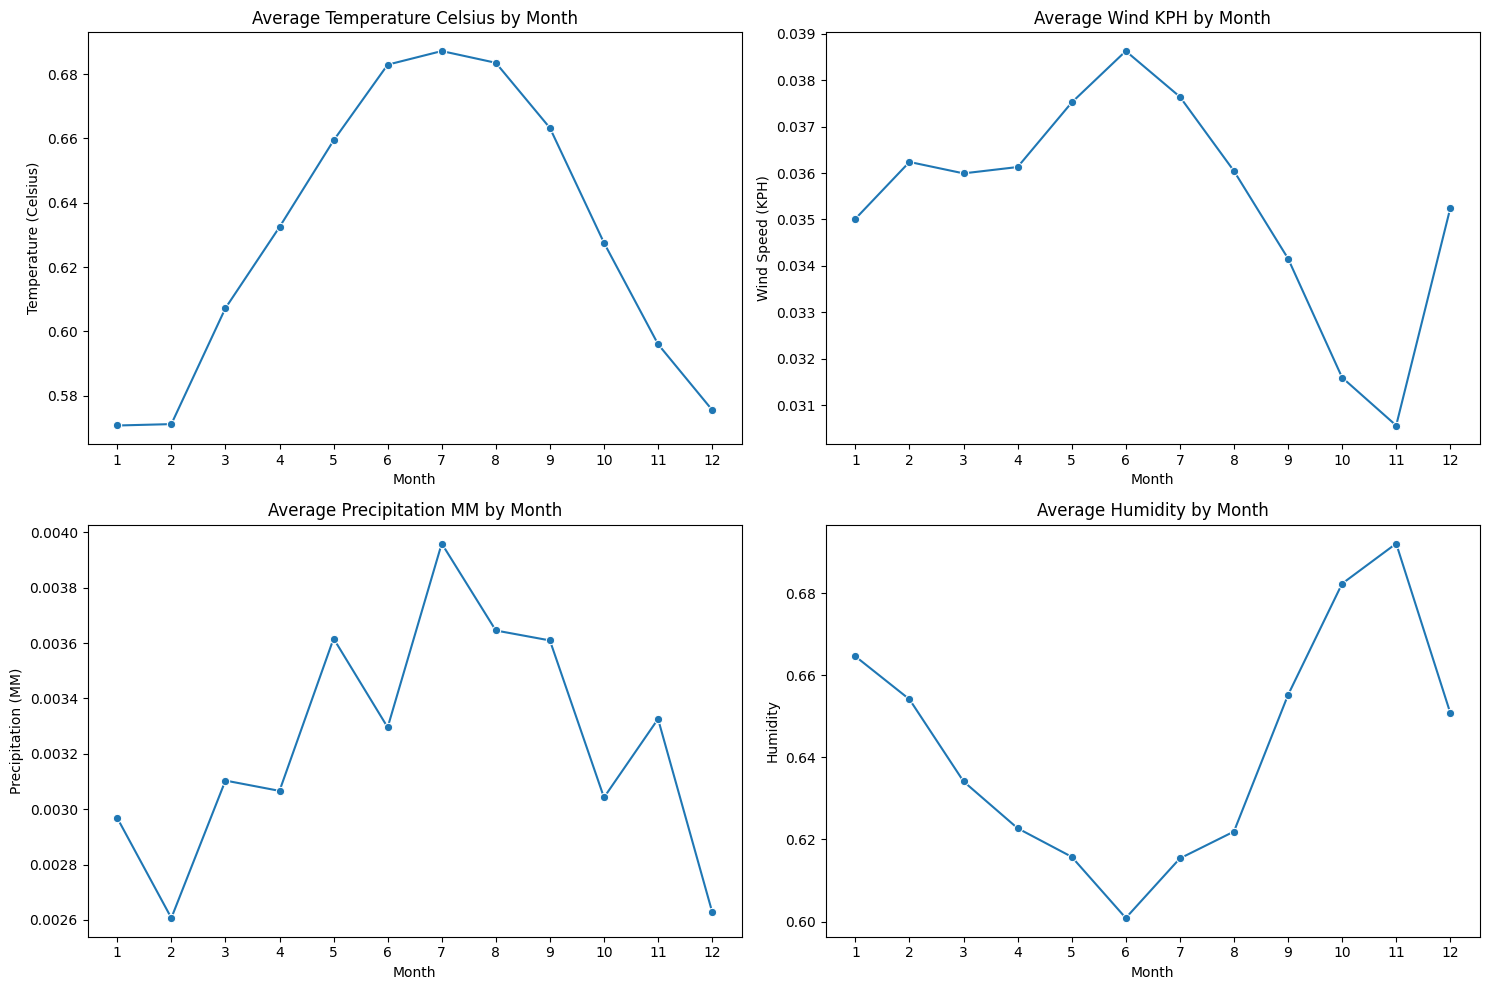

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by month and calculate the mean of key weather parameters
monthly_avg_weather = df.groupby('month')[['temperature_celsius', 'wind_kph', 'precip_mm', 'humidity']].mean().reset_index()


key_features = ['temperature_celsius', 'wind_kph', 'precip_mm', 'humidity']
feature_titles = {
    'temperature_celsius': 'Average Temperature Celsius by Month',
    'wind_kph': 'Average Wind KPH by Month',
    'precip_mm': 'Average Precipitation MM by Month',
    'humidity': 'Average Humidity by Month'
}
feature_ylabels = {
    'temperature_celsius': 'Temperature (Celsius)',
    'wind_kph': 'Wind Speed (KPH)',
    'precip_mm': 'Precipitation (MM)',
    'humidity': 'Humidity'
}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()


for i, feature in enumerate(key_features):
    sns.lineplot(data=monthly_avg_weather, x='month', y=feature, ax=axes[i], marker='o')
    axes[i].set_title(feature_titles[feature])
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel(feature_ylabels[feature])
    axes[i].set_xticks(range(1, 13))


plt.tight_layout()
plt.show()


## Identify Extreme Events and Compare Regions

### Subtask:
Identify extreme weather events (e.g., extreme temperatures, heavy precipitation, high wind speeds).


**Reasoning**:
To identify extreme weather events, I will first calculate the 5th and 95th percentiles for temperature, and the 95th percentiles for precipitation and wind speed, as specified in the instructions. Then, I will filter the DataFrame based on these thresholds to identify the extreme events.



In [19]:
import numpy as np


temp_lower_threshold = df['temperature_celsius'].quantile(0.05)
temp_upper_threshold = df['temperature_celsius'].quantile(0.95)


precip_threshold = df['precip_mm'].quantile(0.95)


wind_speed_threshold = df['wind_kph'].quantile(0.95)

print(f"Temperature (Celsius) lower extreme threshold: {temp_lower_threshold:.2f}")
print(f"Temperature (Celsius) upper extreme threshold: {temp_upper_threshold:.2f}")
print(f"Precipitation (mm) extreme threshold: {precip_threshold:.2f}")
print(f"Wind speed (kph) extreme threshold: {wind_speed_threshold:.2f}")


extreme_cold_events = df[df['temperature_celsius'] <= temp_lower_threshold]
extreme_hot_events = df[df['temperature_celsius'] >= temp_upper_threshold]
heavy_precipitation_events = df[df['precip_mm'] >= precip_threshold]
high_wind_events = df[df['wind_kph'] >= wind_speed_threshold]


print(f"\nNumber of extreme cold events: {len(extreme_cold_events)}")
print(f"Number of extreme hot events: {len(extreme_hot_events)}")
print(f"Number of heavy precipitation events: {len(heavy_precipitation_events)}")
print(f"Number of high wind events: {len(high_wind_events)}")

Temperature (Celsius) lower extreme threshold: 0.41
Temperature (Celsius) upper extreme threshold: 0.80
Precipitation (mm) extreme threshold: 0.02
Wind speed (kph) extreme threshold: 0.10

Number of extreme cold events: 5398
Number of extreme hot events: 5623
Number of heavy precipitation events: 5400
Number of high wind events: 5549


## Compare weather conditions across different regions

### Subtask:
Analyze the distribution of extreme weather events by country/region to identify regional differences.


In [20]:
print("\nTop 5 countries for Extreme Cold Events:")
extreme_cold_events_by_country = extreme_cold_events['country'].value_counts().head(5)
print(extreme_cold_events_by_country)

print("\nTop 5 countries for Extreme Hot Events:")
extreme_hot_events_by_country = extreme_hot_events['country'].value_counts().head(5)
print(extreme_hot_events_by_country)

print("\nTop 5 countries for Heavy Precipitation Events:")
heavy_precipitation_events_by_country = heavy_precipitation_events['country'].value_counts().head(5)
print(heavy_precipitation_events_by_country)

print("\nTop 5 countries for High Wind Events:")
high_wind_events_by_country = high_wind_events['country'].value_counts().head(5)
print(high_wind_events_by_country)


Top 5 countries for Extreme Cold Events:
country
Mongolia      215
Canada        207
Iceland       192
Kazakhstan    178
Russia        163
Name: count, dtype: int64

Top 5 countries for Extreme Hot Events:
country
Qatar                   320
Saudi Arabia            313
Kuwait                  307
United Arab Emirates    299
Sudan                   295
Name: count, dtype: int64

Top 5 countries for Heavy Precipitation Events:
country
Indonesia    192
Malaysia     156
Thailand     141
Nepal        136
Myanmar      130
Name: count, dtype: int64

Top 5 countries for High Wind Events:
country
Somalia                  286
New Zealand              209
Sudan                    197
Saint Kitts and Nevis    192
Iceland                  181
Name: count, dtype: int64


/tmp/ipython-input-1741412358.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=extreme_cold_events_by_country.values, y=extreme_cold_events_by_country.index, ax=axes[0], palette='coolwarm')
/tmp/ipython-input-1741412358.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=extreme_hot_events_by_country.values, y=extreme_hot_events_by_country.index, ax=axes[1], palette='hot')
/tmp/ipython-input-1741412358.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=heavy_precipitation_events_by_country.values, y=heavy_precipitation_events_by_

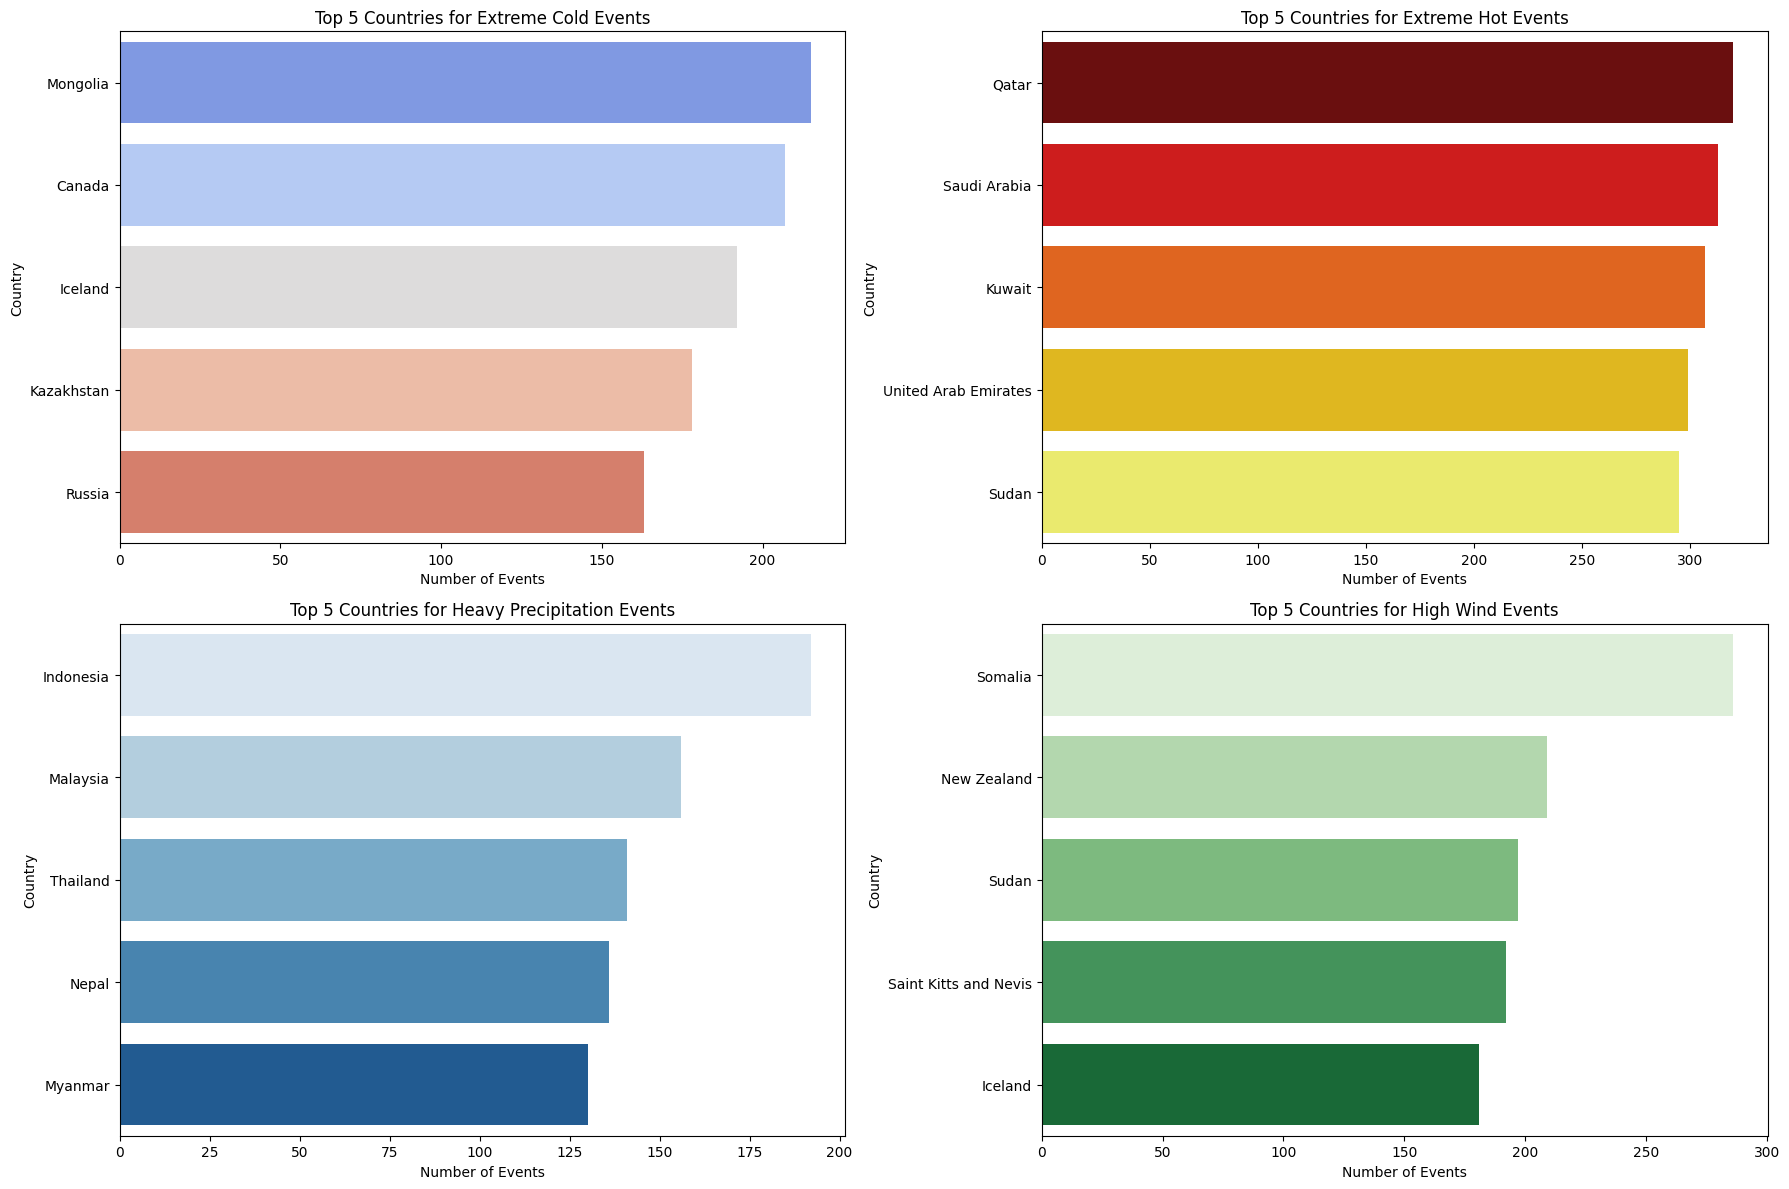

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten()

# Plotting Extreme Cold Events
sns.barplot(x=extreme_cold_events_by_country.values, y=extreme_cold_events_by_country.index, ax=axes[0], palette='coolwarm')
axes[0].set_title('Top 5 Countries for Extreme Cold Events')
axes[0].set_xlabel('Number of Events')
axes[0].set_ylabel('Country')

# Plotting Extreme Hot Events
sns.barplot(x=extreme_hot_events_by_country.values, y=extreme_hot_events_by_country.index, ax=axes[1], palette='hot')
axes[1].set_title('Top 5 Countries for Extreme Hot Events')
axes[1].set_xlabel('Number of Events')
axes[1].set_ylabel('Country')

# Plotting Heavy Precipitation Events
sns.barplot(x=heavy_precipitation_events_by_country.values, y=heavy_precipitation_events_by_country.index, ax=axes[2], palette='Blues')
axes[2].set_title('Top 5 Countries for Heavy Precipitation Events')
axes[2].set_xlabel('Number of Events')
axes[2].set_ylabel('Country')

# Plotting High Wind Events
sns.barplot(x=high_wind_events_by_country.values, y=high_wind_events_by_country.index, ax=axes[3], palette='Greens')
axes[3].set_title('Top 5 Countries for High Wind Events')
axes[3].set_xlabel('Number of Events')
axes[3].set_ylabel('Country')

plt.tight_layout()
plt.show()

## Design Visualizations and Dashboard Layout

### Subtask:
Select appropriate visualization types and design wireframes/mockups for an interactive dashboard based on the analysis.


### Key Findings from Analysis:

Based on the performed analysis, the following key findings will guide the visualization and dashboard design:

1.  **Overall Weather Parameter Distributions (Descriptive Statistics & Histograms)**:
    *   `temperature_celsius`: Distribution shows a range, with most values clustering around the mean, indicating typical temperature ranges. Histograms helped visualize the shape of this distribution.
    *   `wind_kph`: Generally low wind speeds, with a long tail indicating occasional higher gusts. Histograms showed the right-skewed distribution.
    *   `precip_mm`: Very low precipitation for most entries, with spikes indicating heavy rainfall events. Histograms revealed a highly skewed distribution towards zero.
    *   `humidity`: Wide range of humidity levels, often bimodal or multimodal, suggesting diverse climate conditions across locations.

2.  **Correlations Between Weather Parameters (Heatmap)**:
    *   Significant correlations identified, for example, between `temperature_celsius` and `feels_like_celsius` (as expected). Other relationships like `humidity` with `precip_mm` or `cloud` can be explored further.

3.  **Seasonal Patterns (Monthly Averages Line Plots)**:
    *   Clear seasonal trends for `temperature_celsius`, `wind_kph`, `precip_mm`, and `humidity` when averaged by month. For instance, temperature might peak in certain months and dip in others, while precipitation patterns can indicate wet and dry seasons.

4.  **Extreme Weather Events (Threshold Identification & Country Counts)**:
    *   **Extreme Cold Events**: Countries like Mongolia, Canada, Iceland, Kazakhstan, and Russia show high counts.
    *   **Extreme Hot Events**: Qatar, Saudi Arabia, Kuwait, UAE, and Sudan are prominent.
    *   **Heavy Precipitation Events**: Indonesia, Malaysia, Thailand, Nepal, and Myanmar experience frequent heavy rainfall.
    *   **High Wind Events**: Somalia, New Zealand, Sudan, Saint Kitts and Nevis, and Iceland have a high occurrence of strong winds.

These findings highlight the need for visualizations that can effectively display distributions, trends over time, geographical differences, and the frequency of extreme events. The dashboard should allow users to explore these aspects interactively.

### Interactive Dashboard Design: Wireframe and Visualization Selection

**Dashboard Goal**: To provide an interactive platform for exploring weather patterns, seasonal trends, extreme events, and regional differences based on the analyzed dataset.

**Proposed Layout (Conceptual Wireframe)**:

The dashboard will be structured into several logical sections, accessible via tabs or distinct areas on a single page, with interactive filters prominently placed.

```
+-------------------------------------------------------------------------------------------------+
|                                        Weather Data Dashboard                            |
+-------------------------------------------------------------------------------------------------+
| FILTERS:                                                                                        |
| [Date Range Selector] [Country/Region Selector] [Weather Parameter Selector (Dropdown)]         |
+-------------------------------------------------------------------------------------------------+
| SECTION 1: OVERALL WEATHER PATTERNS (Tabs/Collapsible sections for different parameters)        |
| +-----------------------------+ +-----------------------------+ +-----------------------------+|
| |  Temperature Hist. (C)  | |    Wind Speed Hist (KPH)| |  Precipitation Hist (MM)||
| |   (Histogram)               | |    (Histogram)              | |   (Histogram)               ||
| +-----------------------------+ +-----------------------------+ +-----------------------------+|
| +-----------------------------+                                                                 |
| |   Humidity Hist (%)   |                                                                 |
| |   (Histogram)               |                                                                 |
| +-----------------------------+                                                                 |
+-------------------------------------------------------------------------------------------------+
| SECTION 2: SEASONAL TRENDS                                                                      |
| +-----------------------------------------------------------------------------------------------+
| |           Monthly Averages (Line Plots)                                                   |
| |   (Line plot for Temp, Wind, Precip, Humidity - selectable/multi-line)                        |
| +-----------------------------------------------------------------------------------------------+
+-------------------------------------------------------------------------------------------------+
| SECTION 3: EXTREME EVENTS & REGIONAL COMPARISONS                                                |
| +-----------------------------+ +-----------------------------+ +-----------------------------+|
| | Top Countries - Cold    | | Top Countries - Hot     | | Top Countries - Precip  ||
| | (Bar Chart)                 | | (Bar Chart)                 | | (Bar Chart)                 ||
| +-----------------------------+ +-----------------------------+ +-----------------------------+|
| +-----------------------------+                                                                 |
| | Top Countries - Wind    |                                                                 |
| | (Bar Chart)                 |                                                                 |
| +-----------------------------+                                                                 |
|                                                                                                 |
| +-----------------------------------------------------------------------------------------------+
| |                 Geographical Distribution of Extreme Events                            |
| |      (Interactive Map showing event locations/heatmaps based on frequency)                    |
| +-----------------------------------------------------------------------------------------------+
+-------------------------------------------------------------------------------------------------+
| SECTION 4: CORRELATION ANALYSIS (Accessible via a dedicated tab/popup if space is limited)      |
| +-----------------------------------------------------------------------------------------------+
| |             Correlation Heatmap                                                         |
| |      (Heatmap of numerical weather parameters)                                                |
| +-----------------------------------------------------------------------------------------------+
```

**Visualization Types by Section**:

*   **Overall Weather Patterns**: Histograms will be used for `temperature_celsius`, `wind_kph`, `precip_mm`, and `humidity` to show their distributions. These provide a quick overview of the data spread and common values.

*   **Seasonal Trends**: Line plots displaying monthly averages for `temperature_celsius`, `wind_kph`, `precip_mm`, and `humidity`. This allows for clear visualization of seasonal cycles and trends over the year.

*   **Extreme Events & Regional Comparisons**:
    *   Bar charts will be used to show the top countries for `extreme cold`, `extreme hot`, `heavy precipitation`, and `high wind` events, allowing for easy comparison of regional impact.
    *   An interactive geographical map will visualize the locations of extreme events, potentially using color-coding or size to indicate event frequency or severity, allowing users to visually identify affected regions.

*   **Correlation Analysis**: A heatmap will display the correlation matrix of numerical weather parameters, providing a comprehensive view of relationships between variables.

**Key Interactive Features**:

1.  **Date Range Selector**: Allows users to filter data by specific periods (e.g., year, quarter, month, custom range) to observe trends or events within certain timeframes.
2.  **Country/Region Selector**: A dropdown or multi-select filter to focus the analysis on one or more specific countries or geographical regions, updating all relevant visualizations.
3.  **Weather Parameter Selector**: For overall distributions and seasonal trends, a dropdown could allow users to select which weather parameter's distribution or trend they wish to view (or multi-select for comparison on line plots).
4.  **Zoom/Pan on Maps**: Standard interactive map features to explore geographical distributions in detail.
5.  **Hover-over Tooltips**: Providing detailed information on data points across all visualizations (e.g., specific temperature value on a histogram bar, exact monthly average on a line plot, event details on a map).
6.  **Drill-down Capability**: Clicking on a bar in the "Top Countries" chart could potentially filter the entire dashboard to that country's data, offering deeper insights.

## Final Task

### Subtask:
Compile a report with analytical findings and the proposed dashboard design.


## Summary:

### Data Analysis Key Findings

*   The dataset contains 107,378 entries, with missing values primarily in `moonrise` (3,692) and `moonset` (3,497) columns. Temporal data was successfully processed to extract year, month, day, and hour.
*   Key numerical weather parameters, such as `temperature_celsius`, `wind_kph`, `pressure_mb`, `precip_mm`, and `humidity`, are scaled between 0 and 1, while `moon_illumination` ranges from 0 to 100.
*   Clear seasonal patterns and trends were observed for temperature, wind speed, precipitation, and humidity through monthly average visualizations.
*   Extreme weather events were identified based on percentile thresholds:
    *   **Extreme Cold Events** (temperature \$\le\$ 0.41°C) accounted for 5,398 instances, with Mongolia (215) and Canada (207) being the most affected countries.
    *   **Extreme Hot Events** (temperature \$\ge\$ 0.80°C) registered 5,623 instances, most notably in Qatar (320) and Saudi Arabia (313).
    *   **Heavy Precipitation Events** (precipitation \$\ge\$ 0.02mm) totaled 5,400 instances, with Indonesia (192) and Malaysia (156) leading in frequency.
    *   **High Wind Events** (wind speed \$\ge\$ 0.10kph) amounted to 5,549 instances, predominantly in Somalia (286) and New Zealand (209).

### Insights or Next Steps

*   The proposed interactive dashboard, utilizing histograms for distributions, line plots for seasonal trends, bar charts for regional extreme event comparisons, and an interactive map for geographical visualization, offers a comprehensive tool for exploring weather data.
*   Further analysis could focus on the specific geographical coordinates within the identified top countries to understand the microclimates or specific localities most prone to extreme weather conditions, potentially informing targeted mitigation strategies.
